# ECG Segmentation Pipeline
**Content of the file:** This file performs the segmentations P-QRS-T on the ECGs and aligns peak R. Its the prevoius step to any machine learning model to unify data. It expects the clean parquet file with an ECG per row with leads and patient Id as columns. It  outputs the qrs segments in aligned_qrs.pkl and the whole segmented signal in segmentations.pkl


**Pipeline:**
```
Parquet → matrices (n,12) → downsample 250Hz → filter → ensemble 5 models → P/QRS/T segmentation mask → detect R peak → align → save
```

# Imports & Paths

In [1]:
# del document requirements de github
#!pip install -q git+https://github.com/guillermo-jimenez/sak.git
#!pip install -q scipy scikit-image pandas numpy matplotlib tqdm
#!pip install -r requirements.txt

In [ ]:
import gc
import math
import os
import pickle
import warnings
from pathlib import Path
from typing import Dict, List, Optional, Tuple
from functools import partial
import numpy as np
import pandas as pd
import scipy as sp
import skimage
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
from tqdm import tqdm
import timm
import contextlib
import random
import torch
import sak


warnings.filterwarnings('ignore')

# Global plot style
plt.rcParams.update({
    'figure.facecolor': '#FAFAFA',
    'axes.facecolor':   '#FFFFFF',
    'axes.edgecolor':   '#CCCCCC',
    'axes.labelcolor':  '#333333',
    'axes.titlesize':   10,
    'axes.titleweight': 'bold',
    'xtick.color':      '#666666',
    'ytick.color':      '#666666',
    'grid.color':       '#E5E5E5',
    'grid.linewidth':   0.8,
    'font.family':      'DejaVu Sans',
})

WAVE_NAMES   = ['P', 'QRS', 'T']
WAVE_COLORS  = {'P': '#74B9FF', 'QRS': '#FF7675', 'T': '#55EFC4'}
LEAD_NAMES   = ['I','II','III','aVR','aVL','aVF','V1','V2','V3','V4','V5','V6']
SIGNAL_COLOR = '#2D3436'

print(' Imports OK')
print(f'   PyTorch  {torch.__version__}')
print(f'   Numpy    {np.__version__}')
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'   Device   {device.upper()}')

c:\Users\maria\anaconda3\envs\CompBioMed26\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


 Imports OK
   PyTorch  2.4.1+cpu
   Numpy    1.24.4
   Device   CPU


In [ ]:

DATA_PATH   = "data/binary_full_dataset.parquet"         
MODELS_DIR  = "models"                
OUTPUT_DIR  = "outputs" 

LEAD_COLS = ['I','II','III','AVR','AVL','AVF','V1','V2','V3','V4','V5','V6']

PATIENT_COL = 'patient_id'

LABEL_COLS  = ['Chamber_Type', 'Final_label'] 

# Signal Parameters
FS          = 1000    # Hz parquet
FS_MODEL    = 250     # Hz expected
SIGNAL_LEN  = 2500    # expected samples per ECG (2.5s × 1000 Hz)

# Output paths
os.makedirs(OUTPUT_DIR, exist_ok=True)
CACHE_SEG   = os.path.join(OUTPUT_DIR, 'segmentations.pkl')
CACHE_ALI   = os.path.join(OUTPUT_DIR, 'aligned_ecgs.pkl')
CACHE_IDS   = os.path.join(OUTPUT_DIR, 'identifiers.pkl')

print(' Configured Paths:')
print(f'   Data   → {DATA_PATH}')
print(f'   Models → {MODELS_DIR}')
print(f'   Outputs → {OUTPUT_DIR}')

 Configured Paths:
   Data   → data/binary_full_dataset.parquet
   Models → models
   Outputs → outputs


### Data Loading

The parquet file must contain one row per ECG with:
- One column per lead (I, II, ..., V6): each cell must be an array/list of 2500 floats (2.5 s × 1000 Hz).
- One column for the patient ID.
- Optional label/target columns


In [4]:
df = pd.read_parquet(DATA_PATH)
print(f' Loading dataset: {len(df)} ECGs, {df.shape[1]} columns')
print(f'   Columns: {list(df.columns)}')
print()

# Verify signal format
sample_row = df.iloc[0]
print(' Verification of signal format:')
for lead in LEAD_COLS:
    sig = sample_row[lead]
    print(f'   {lead:>4}: tipo={type(sig).__name__}, longitud={len(sig)}, '
          f'dtype={np.array(sig).dtype}, rango=[{np.min(sig):.3f}, {np.max(sig):.3f}]')

print()
print(' OK' if all(len(sample_row[l]) == SIGNAL_LEN for l in LEAD_COLS)
      else f'⚠️  Expected length: {SIGNAL_LEN}.')

 Loading dataset: 180 ECGs, 28 columns
   Columns: ['patient_id', 'I', 'II', 'III', 'AVR', 'AVL', 'AVF', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'Sex', 'HTA', 'Age', 'PVC_transition', 'Height', 'Weight', 'BMI', 'DM', 'DLP', 'Smoker', 'COPD', 'Sleep_apnea', 'CLINICAL_SCORE', 'missing_rate', 'Chamber_Type']

 Verification of signal format:
      I: tipo=ndarray, longitud=2500, dtype=float64, rango=[-0.270, 0.447]
     II: tipo=ndarray, longitud=2500, dtype=float64, rango=[-0.750, 1.629]
    III: tipo=ndarray, longitud=2500, dtype=float64, rango=[-0.645, 1.518]
    AVR: tipo=ndarray, longitud=2500, dtype=float64, rango=[-0.777, 0.444]
    AVL: tipo=ndarray, longitud=2500, dtype=float64, rango=[-0.969, 0.435]
    AVF: tipo=ndarray, longitud=2500, dtype=float64, rango=[-0.696, 1.524]
     V1: tipo=ndarray, longitud=2500, dtype=float64, rango=[-0.561, 0.423]
     V2: tipo=ndarray, longitud=2500, dtype=float64, rango=[-0.717, 0.774]
     V3: tipo=ndarray, longitud=2500, dtype=float64, rango=[-0.8

In [24]:
def build_ecg_matrices(df: pd.DataFrame,
                        lead_cols: List[str],
                        patient_col: str,
                        label_cols: List[str],
                        expected_len: int = 2500
                        ) -> Tuple[List[np.ndarray], pd.DataFrame]:
    """
    Converts the DataFrame into a list of matrices (expected_len, 12)
    and a metadata DataFrame with an aligned index.

    Filters out ECGs with incorrect lead lengths or NaN/Inf values.
    """
    ecg_matrices = []
    valid_idx     = []
    skipped       = {'len': 0, 'nan': 0, 'other': 0}

    for i, row in tqdm(df.iterrows(), total=len(df), desc='Building ECG matrices'):
        try:
            signals = [np.array(row[lead], dtype=np.float32) for lead in lead_cols]

            # Check length
            lengths = [len(s) for s in signals]
            if len(set(lengths)) != 1 or lengths[0] != expected_len:
                skipped['len'] += 1
                continue

            matrix = np.stack(signals, axis=1)   # (expected_len, 12)

            # Check NaN/Inf
            if not np.isfinite(matrix).all():
                skipped['nan'] += 1
                continue

            ecg_matrices.append(matrix)
            valid_idx.append(i)

        except Exception as e:
            skipped['other'] += 1

    # Metadata aligned with the preserved ECGs
    meta_cols = [patient_col] + [c for c in label_cols if c in df.columns]
    identifiers = df.loc[valid_idx, meta_cols].reset_index(drop=True)

    total = len(df)
    kept  = len(ecg_matrices)
    print(f'\n Matrix construction summary:')
    print(f'   Total input ECGs  : {total}')
    print(f'   Valid ECGs        : {kept} ({kept/total*100:.1f}%)')
    print(f'   Skipped (incorrect length) : {skipped["len"]}')
    print(f'   Skipped (NaN/Inf)          : {skipped["nan"]}')
    print(f'   Skipped (other errors)     : {skipped["other"]}')
    print(f'   Shape of each matrix : {ecg_matrices[0].shape}')
    return ecg_matrices, identifiers


ecg_matrices, identifiers = build_ecg_matrices(
    df, LEAD_COLS, PATIENT_COL, LABEL_COLS, expected_len=SIGNAL_LEN
)

Building ECG matrices: 100%|██████████| 180/180 [00:00<00:00, 1090.07it/s]


 Matrix construction summary:
   Total input ECGs  : 180
   Valid ECGs        : 180 (100.0%)
   Skipped (incorrect length) : 0
   Skipped (NaN/Inf)          : 0
   Skipped (other errors)     : 0
   Shape of each matrix : (2500, 12)


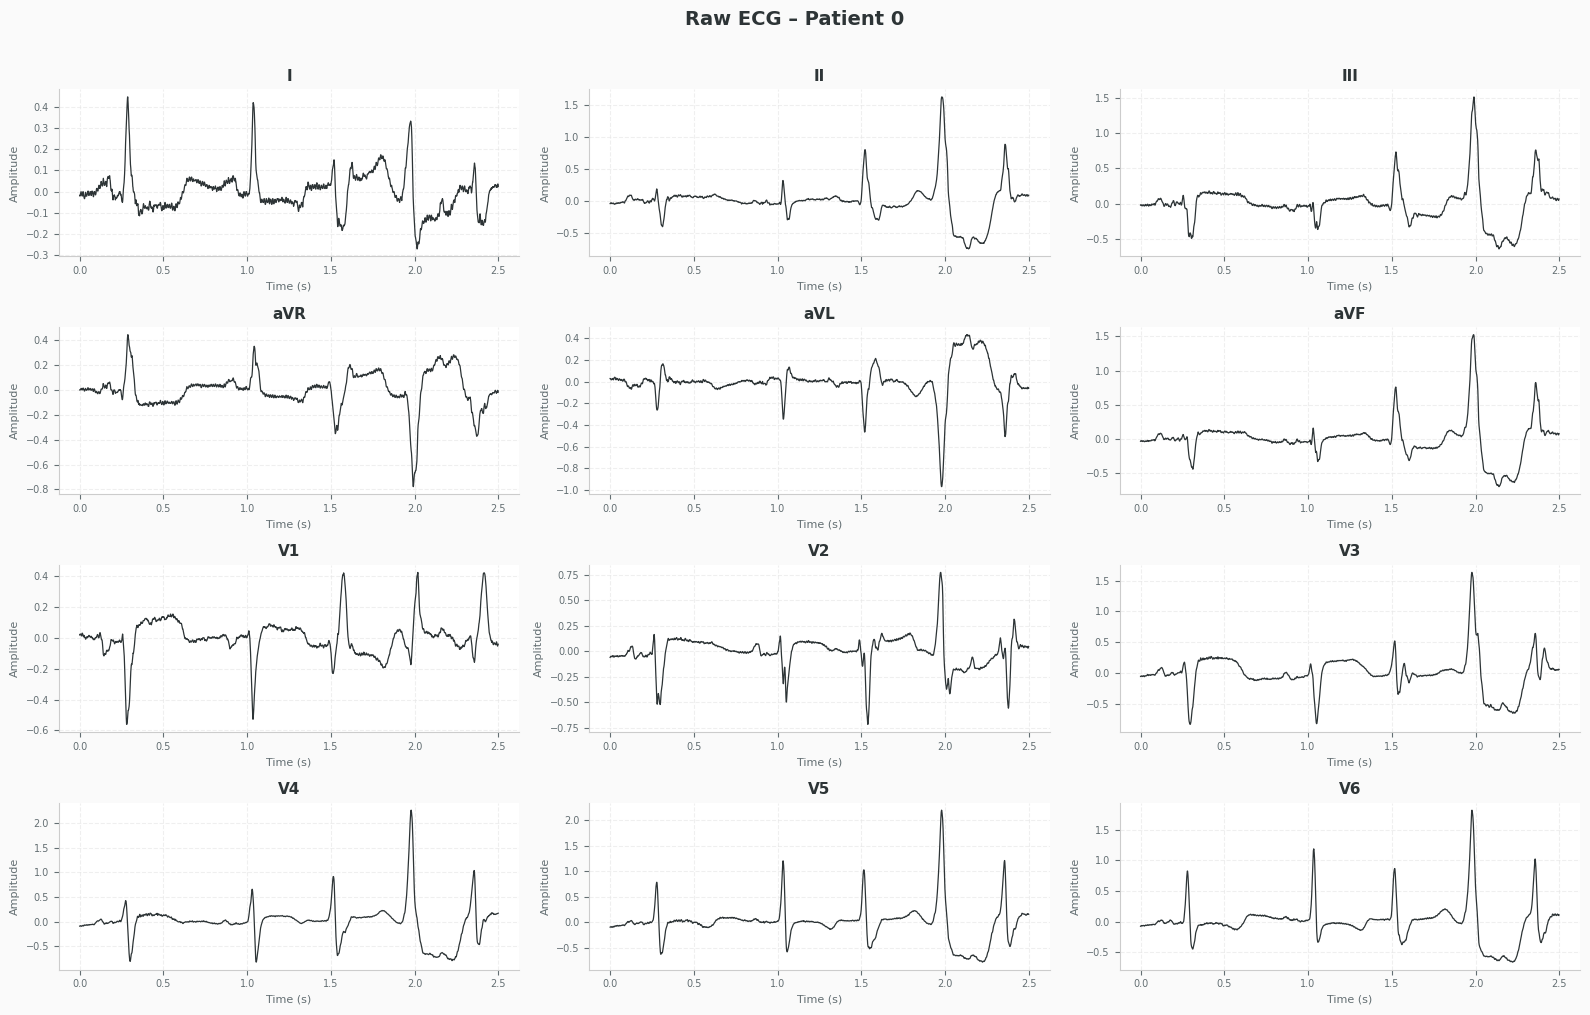

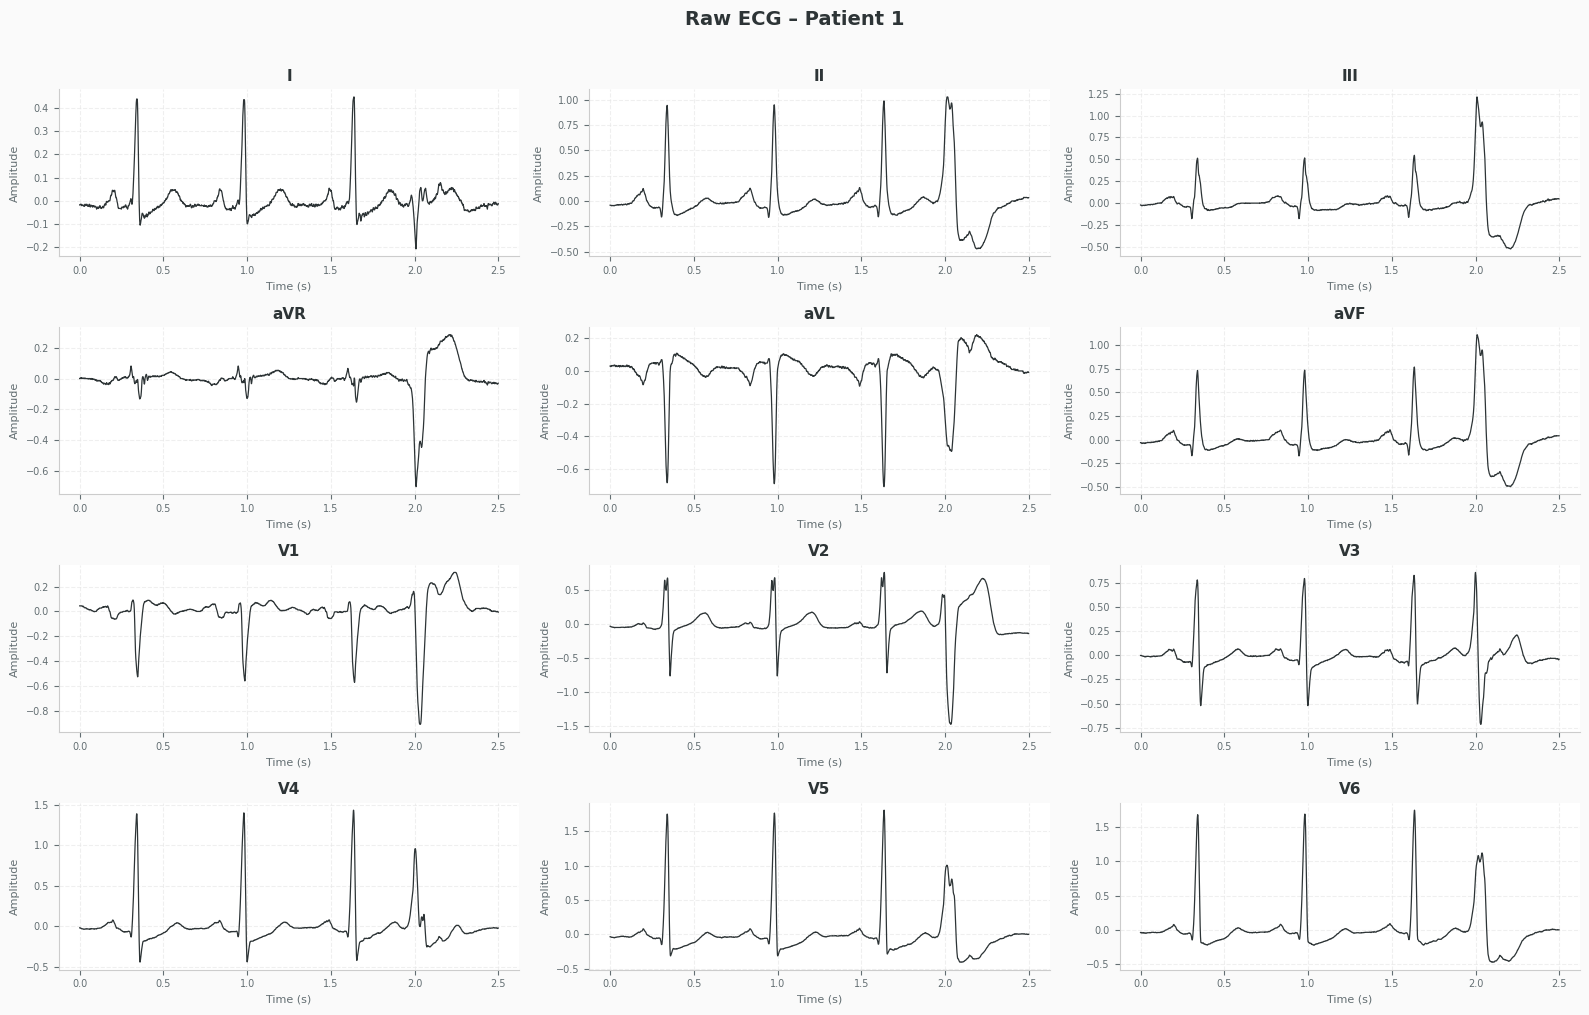

In [ ]:
def plot_raw_ecg(ecg_matrix: np.ndarray, fs: int = 1000,
                 title: str = ' Raw ECG - 12 Leads'):
    """Displays the 12 ECG leads in a 4x3 grid."""
    fig, axes = plt.subplots(4, 3, figsize=(16, 10))
    fig.patch.set_facecolor('#FAFAFA')
    x = np.arange(ecg_matrix.shape[0]) / fs

    for i, ax in enumerate(axes.flat):
        sig = ecg_matrix[:, i]
        ax.plot(x, sig, color=SIGNAL_COLOR, linewidth=0.9)
        ax.set_title(LEAD_NAMES[i], fontsize=11, fontweight='bold', color='#2D3436')
        ax.set_xlabel('Time (s)', fontsize=8, color='#636E72')
        ax.set_ylabel('Amplitude', fontsize=8, color='#636E72')
        ax.grid(True, linestyle='--', alpha=0.6)
        ax.spines[['top','right']].set_visible(False)
        ax.tick_params(labelsize=7, colors='#636E72')

    fig.suptitle(title, fontsize=14, fontweight='bold', color='#2D3436', y=1.01)
    plt.tight_layout()
    plt.show()


# Display 2 example ECGs
for i in [0, 1]:
    pid = identifiers.iloc[i][PATIENT_COL]
    plot_raw_ecg(ecg_matrices[i], title=f'Raw ECG – Patient {pid}')

In [ ]:
# Verify the shape
test_ecg_matrix = ecg_matrices[17]
print(f"First ECG matrix shape: {test_ecg_matrix.shape}")

First ECG matrix shape: (2500, 12)


### Loading the segmentation models
These models are used to find the most accurate segmentation of the signal.

In [27]:
def load_models(models_dir: str) -> List[torch.nn.Module]:
    """Loads the 5 segmentation models (model.1 ... model.5)."""
    models = []
    for i in range(1, 6):
        path = os.path.join(models_dir, f'model.{i}')
        if not os.path.exists(path):
            raise FileNotFoundError(f'Not found: {path}')
        m = torch.load(path)
        m.eval().float()
        models.append(m)
    print(f' {len(models)} segmentation models successfully loaded')
    for i, m in enumerate(models):
        print(f'   Model {i+1}: {type(m).__name__}')
    return models


models_ECG = load_models(MODELS_DIR)

 5 segmentation models successfully loaded
   Model 1: ModelGraph
   Model 2: ModelGraph
   Model 3: ModelGraph
   Model 4: ModelGraph
   Model 5: ModelGraph


### Segmentation function

This function has:
- robust normalization of the signal with sak.signal.moving_lambda
- Notch filters to handle powerline interference
- FFT-based resampling
- Upscaling to save correspondency with original samples


In [ ]:

# Patch: torch.no_grad() en versions noves no és compatible amb sak antic
# Substituïm per un context manager que no fa res
class _NoGrad:
    def __enter__(self):
        return self
    def __exit__(self, *args):
        pass
    def __call__(self, func):
        return func

torch.no_grad = _NoGrad
print("Patch torch.no_grad OK")

Patch torch.no_grad OK


In [28]:
def predict_ecg(ecg: np.ndarray,
                fs: float,
                model: List[torch.nn.Module],
                window_size: int = 2048,
                stride: int = 256,
                threshold_ensemble: float = 0.5,
                thr_dice: float = 0.9,
                percentile: int = 95,
                ptg_voting: float = 0.5,
                batch_size: int = 16,
                normalize: bool = True,
                norm_threshold: float = 1e-6,
                filter: bool = True) -> np.ndarray:
    """
    Segments an ECG of arbitrary size into P, QRS, and T waves.

    Input : ecg  (SAMPLES x LEADS), fs in Hz
    Output: mask (3 x SAMPLES) - row 0=P, 1=QRS, 2=T

     """
    ecg_orig = np.copy(ecg).squeeze()
    if ecg_orig.ndim == 1:
        ecg_orig = ecg_orig[:, None]
    elif ecg_orig.ndim == 2 and ecg_orig.shape[0] < ecg_orig.shape[1]:
        ecg_orig = ecg_orig.T

    # Resample to 250 Hz 
    if fs != 250:
        ecg_250 = sp.signal.resample(ecg_orig, int(ecg_orig.shape[0] * 250 / fs), axis=0)
    else:
        ecg_250 = ecg_orig.copy()

    # Padding 
    padding = 0
    if ecg_250.shape[0] < window_size:
        padding = math.ceil(ecg_250.shape[0] / window_size) * window_size - ecg_250.shape[0]
        ecg_250 = np.pad(ecg_250, ((0, padding), (0, 0)), mode='edge')
    if (ecg_250.shape[0] - window_size) % stride != 0:
        extra = math.ceil((ecg_250.shape[0] - window_size) / stride) * stride - (ecg_250.shape[0] % window_size)
        padding += extra
        ecg_250 = np.pad(ecg_250, ((0, extra), (0, 0)), mode='edge')

    N, L = ecg_250.shape

    #  Robust Normalization 
    if normalize:
        norm_signal = ecg_250[np.all(np.abs(np.diff(ecg_250, axis=0, append=0)) >= norm_threshold, axis=1), :]
        if len(norm_signal) > 0:
            norm_signal = sp.signal.filtfilt(
                *sp.signal.butter(2, 0.5 / 250., 'high'), norm_signal, axis=0
            )
            amplitude = np.array(sak.signal.moving_lambda(
                norm_signal, 256,
                partial(sak.signal.amplitude, axis=0), axis=0
            ))
            amplitude = amplitude[np.all(amplitude > norm_threshold, axis=1), :]
            if len(amplitude) > 0:
                amplitude = np.percentile(amplitude, percentile, axis=0)
                ecg_250 = ecg_250 / amplitude[None, :]

    #  Filtering: band-pass + 50/60 Hz notch 
    if filter:
        ecg_250 = sp.signal.filtfilt(*sp.signal.butter(2,   0.5 / 250., 'high'), ecg_250, axis=0)
        rose = sp.signal.filtfilt(*sp.signal.butter(2, 125.0 / 250.,  'low'), ecg_250, axis=0)
        ecg_250 = sp.signal.lfilter(*sp.signal.iirnotch(50, 20.0, 250.), ecg_250, axis=0)   # EU power grid
        ecg_250 = sp.signal.lfilter(*sp.signal.iirnotch(60, 20.0, 250.), ecg_250, axis=0)   # US power grid

    if np.any(np.array(ecg_250.strides) < 0):
        ecg_250 = ecg_250.copy()

    # Sliding Windows 
    windowed = skimage.util.view_as_windows(ecg_250, (window_size, 1), (stride, 1))
    new_shape = (windowed.shape[0] * windowed.shape[1], *windowed.shape[2:])
    windowed = np.reshape(windowed, new_shape).swapaxes(1, 2)
    windowed_mask = np.zeros((windowed.shape[0], 3, windowed.shape[-1]), dtype=int)

    # Ensemble Inference 
    with torch.no_grad():
        if isinstance(model, list):
            for m in model:
                m = m.to(device)
                for i in range(0, windowed.shape[0], batch_size):
                    inputs = {'x': torch.tensor(windowed[i:i+batch_size]).float().to(device)}
                    outputs = m(inputs)['sigmoid'].cpu().detach().numpy()
                    windowed_mask[i:i+batch_size] += outputs > thr_dice
            windowed_mask = windowed_mask >= len(model) * threshold_ensemble

        else:
            model = model.to(device)
            for i in range(0, windowed.shape[0], batch_size):
                inputs = {'x': torch.tensor(windowed[i:i+batch_size]).float().to(device)}
                outputs = model(inputs)['sigmoid'].cpu().detach().numpy()
                windowed_mask[i:i+batch_size] = outputs > thr_dice

    # Reconstruct Full Mask at 250 Hz 
    counter = np.zeros(N, dtype=int)
    seg_250 = np.zeros((3, N))
    for i in range(0, windowed_mask.shape[0], L):
        start = (i // L) * stride
        counter[start:start + window_size] += 1
        seg_250[:, start:start + window_size] += windowed_mask[i:i+L].sum(0)
    seg_250 = (seg_250 / counter) >= (ecg_250.shape[-1] * ptg_voting)

    # Remove Padding and Upscale to Original fs
    if padding:
        seg_250 = seg_250[:, :-padding]

    segmentation = sak.signal.interpolate.interp1d(
        seg_250, ecg_orig.shape[0], axis=-1, kind='nearest'
    )
    return segmentation   # shape: (3, n_samples_orig)

### Extracting the segments and visualitzation

In [29]:
def extract_segments(mask: np.ndarray) -> Dict[str, List[Tuple[int, int]]]:
    """Converts the binary mask (3, n) → dictionary {wave_name: [(start, end), ...]}."""
    segs = {name: [] for name in WAVE_NAMES}
    for i, name in enumerate(WAVE_NAMES):
        row = mask[i].astype(int)
        starts = np.where(np.diff(np.hstack(([0], row)))  ==  1)[0]
        ends   = np.where(np.diff(np.hstack((row, [0])))  == -1)[0]
        for s, e in zip(starts, ends):
            segs[name].append((int(s), int(e)))
    return segs


def print_segments(segs: Dict):
    for wave, intervals in segs.items():
        if intervals:
            parts = ', '.join(f'[{s}–{e}] ({e-s} ms)' for s, e in intervals)
        else:
            parts = 'not detected'
        print(f'   {wave:3s}: {parts}')


def plot_segmentation_12leads(ecg_matrix: np.ndarray, segments: Dict,
                               fs: int = 1000, title: str = None,
                               show_legend: bool = True):
    """Plots 12 leads with shaded waves: P (blue), QRS (red), T (green)."""
    fig, axes = plt.subplots(4, 3, figsize=(16, 11))
    fig.patch.set_facecolor('#FAFAFA')
    x = np.arange(ecg_matrix.shape[0]) / fs

    for i, ax in enumerate(axes.flat):
        sig = ecg_matrix[:, i]
        ax.plot(x, sig, color=SIGNAL_COLOR, linewidth=0.9, zorder=3)

        for wave, color in WAVE_COLORS.items():
            for (s, e) in segments.get(wave, []):
                ax.axvspan(s / fs, e / fs, color=color, alpha=0.35, zorder=1)

        ax.set_title(LEAD_NAMES[i], fontsize=11, fontweight='bold', color='#2D3436')
        ax.set_xlabel('Time (s)', fontsize=8, color='#636E72')
        ax.set_ylabel('mV', fontsize=8, color='#636E72')
        ax.grid(True, alpha=0.5)
        ax.spines[['top','right']].set_visible(False)
        ax.tick_params(labelsize=7, colors='#636E72')

    if show_legend:
        patches = [mpatches.Patch(color=WAVE_COLORS[w], alpha=0.6, label=f'{w} Wave')
                   for w in WAVE_NAMES]
        fig.legend(handles=patches, loc='lower center', ncol=3,
                   fontsize=10, frameon=True, bbox_to_anchor=(0.5, -0.02),
                   facecolor='white', edgecolor='#CCCCCC')

    if title:
        fig.suptitle(title, fontsize=14, fontweight='bold', color='#2D3436')
    plt.tight_layout()
    plt.subplots_adjust(bottom=0.07)
    plt.show()


def plot_lead_detail(ecg_matrix: np.ndarray, segments: Dict,
                     lead_idx: int = 1, fs: int = 1000, title: str = None):
    """
    Detailed view of a SINGLE lead featuring:
    - Wave shading
    - Boundaries marking the start/end of each segment
    - Duration annotations
    """
    sig = ecg_matrix[:, lead_idx]
    x   = np.arange(len(sig)) / fs

    fig, ax = plt.subplots(figsize=(14, 4))
    fig.patch.set_facecolor('#FAFAFA')
    ax.plot(x, sig, color=SIGNAL_COLOR, linewidth=1.3, zorder=4, label=f'Lead {LEAD_NAMES[lead_idx]}')

    for wave, color in WAVE_COLORS.items():
        for j, (s, e) in enumerate(segments.get(wave, [])):
            t_s, t_e = s / fs, e / fs
            ax.axvspan(t_s, t_e, color=color, alpha=0.35, zorder=1,
                       label=f'{wave} Wave' if j == 0 else None)
            # Boundary lines
            ax.axvline(t_s, color=color, linewidth=1.2, linestyle='--', alpha=0.8, zorder=2)
            ax.axvline(t_e, color=color, linewidth=1.2, linestyle='--', alpha=0.8, zorder=2)
            # Duration annotation
            dur_ms = (e - s)
            y_text = sig.max() * 0.9
            ax.text((t_s + t_e) / 2, y_text, f'{wave}\n{dur_ms} ms',
                    ha='center', va='top', fontsize=8, color=color,
                    fontweight='bold', zorder=5)

    ax.set_xlabel('Time (s)', fontsize=10, color='#636E72')
    ax.set_ylabel('Amplitude (mV)', fontsize=10, color='#636E72')
    ax.grid(True, alpha=0.4)
    ax.spines[['top','right']].set_visible(False)
    ax.tick_params(colors='#636E72')
    ax.legend(loc='upper right', fontsize=9, frameon=True,
              facecolor='white', edgecolor='#CCCCCC')
    if title:
        ax.set_title(title, fontsize=12, fontweight='bold', color='#2D3436')
    plt.tight_layout()
    plt.show()


def plot_segmentation_summary(ecg_matrix: np.ndarray, segments: Dict,
                               fs: int = 1000, patient_id: str = ''):
    """
    Comprehensive dashboard for an ECG: Detailed Lead II (top) + 12 leads grid (bottom).
    """
    fig = plt.figure(figsize=(16, 14))
    fig.patch.set_facecolor('#FAFAFA')
    gs  = gridspec.GridSpec(5, 3, figure=fig, hspace=0.45, wspace=0.3)

    # Expanded Lead II (row 0, spans all 3 columns)
    ax_ii = fig.add_subplot(gs[0, :])
    sig_ii = ecg_matrix[:, 1]
    x = np.arange(len(sig_ii)) / fs
    ax_ii.plot(x, sig_ii, color=SIGNAL_COLOR, linewidth=1.2, zorder=4)
    for wave, color in WAVE_COLORS.items():
        for j, (s, e) in enumerate(segments.get(wave, [])):
            ax_ii.axvspan(s/fs, e/fs, color=color, alpha=0.35, zorder=1,
                          label=f'{wave} Wave' if j == 0 else None)
            ax_ii.text((s+e)/(2*fs), sig_ii.max()*0.85,
                       f'{wave}\n{e-s}ms', ha='center', va='top',
                       fontsize=8, color=color, fontweight='bold')
    ax_ii.set_title('Lead II – Detailed view with segmentation', fontsize=11, fontweight='bold')
    ax_ii.set_xlabel('Time (s)', fontsize=9)
    ax_ii.grid(True, alpha=0.4)
    ax_ii.spines[['top','right']].set_visible(False)
    ax_ii.legend(loc='upper right', fontsize=9, frameon=True,
                 facecolor='white', edgecolor='#CCCCCC')

    # 12 leads grid (rows 1-4)
    for i in range(12):
        row = (i // 3) + 1
        col = i % 3
        ax = fig.add_subplot(gs[row, col])
        sig = ecg_matrix[:, i]
        ax.plot(x, sig, color=SIGNAL_COLOR, linewidth=0.8, zorder=3)
        for wave, color in WAVE_COLORS.items():
            for (s, e) in segments.get(wave, []):
                ax.axvspan(s/fs, e/fs, color=color, alpha=0.30, zorder=1)
        ax.set_title(LEAD_NAMES[i], fontsize=10, fontweight='bold', color='#2D3436')
        ax.grid(True, alpha=0.4)
        ax.spines[['top','right']].set_visible(False)
        ax.tick_params(labelsize=7, colors='#636E72')

    # Global legend
    patches = [mpatches.Patch(color=WAVE_COLORS[w], alpha=0.6, label=f'{w} Wave')
               for w in WAVE_NAMES]
    fig.legend(handles=patches, loc='lower center', ncol=3, fontsize=10,
               frameon=True, bbox_to_anchor=(0.5, -0.01),
               facecolor='white', edgecolor='#CCCCCC')

    pid_str = f' – Patient {patient_id}' if patient_id else ''
    fig.suptitle(f'P-QRS-T Segmentation{pid_str}', fontsize=14,
                 fontweight='bold', color='#2D3436', y=1.005)
    plt.show()


print(' Visualization functions successfully defined')

 Visualization functions successfully defined


Trial in a single patient to ensure everything is working as expected

Segmenting test ECG (patient 1)...

 Detected segments:
   P  : [123–242] (119 ms), [763–883] (120 ms), [1416–1535] (119 ms)
   QRS: [291–386] (95 ms), [932–1027] (95 ms), [1584–1684] (100 ms), [1949–2092] (143 ms)
   T  : [455–650] (195 ms), [1100–1291] (191 ms), [1761–1940] (179 ms), [2093–2320] (227 ms)


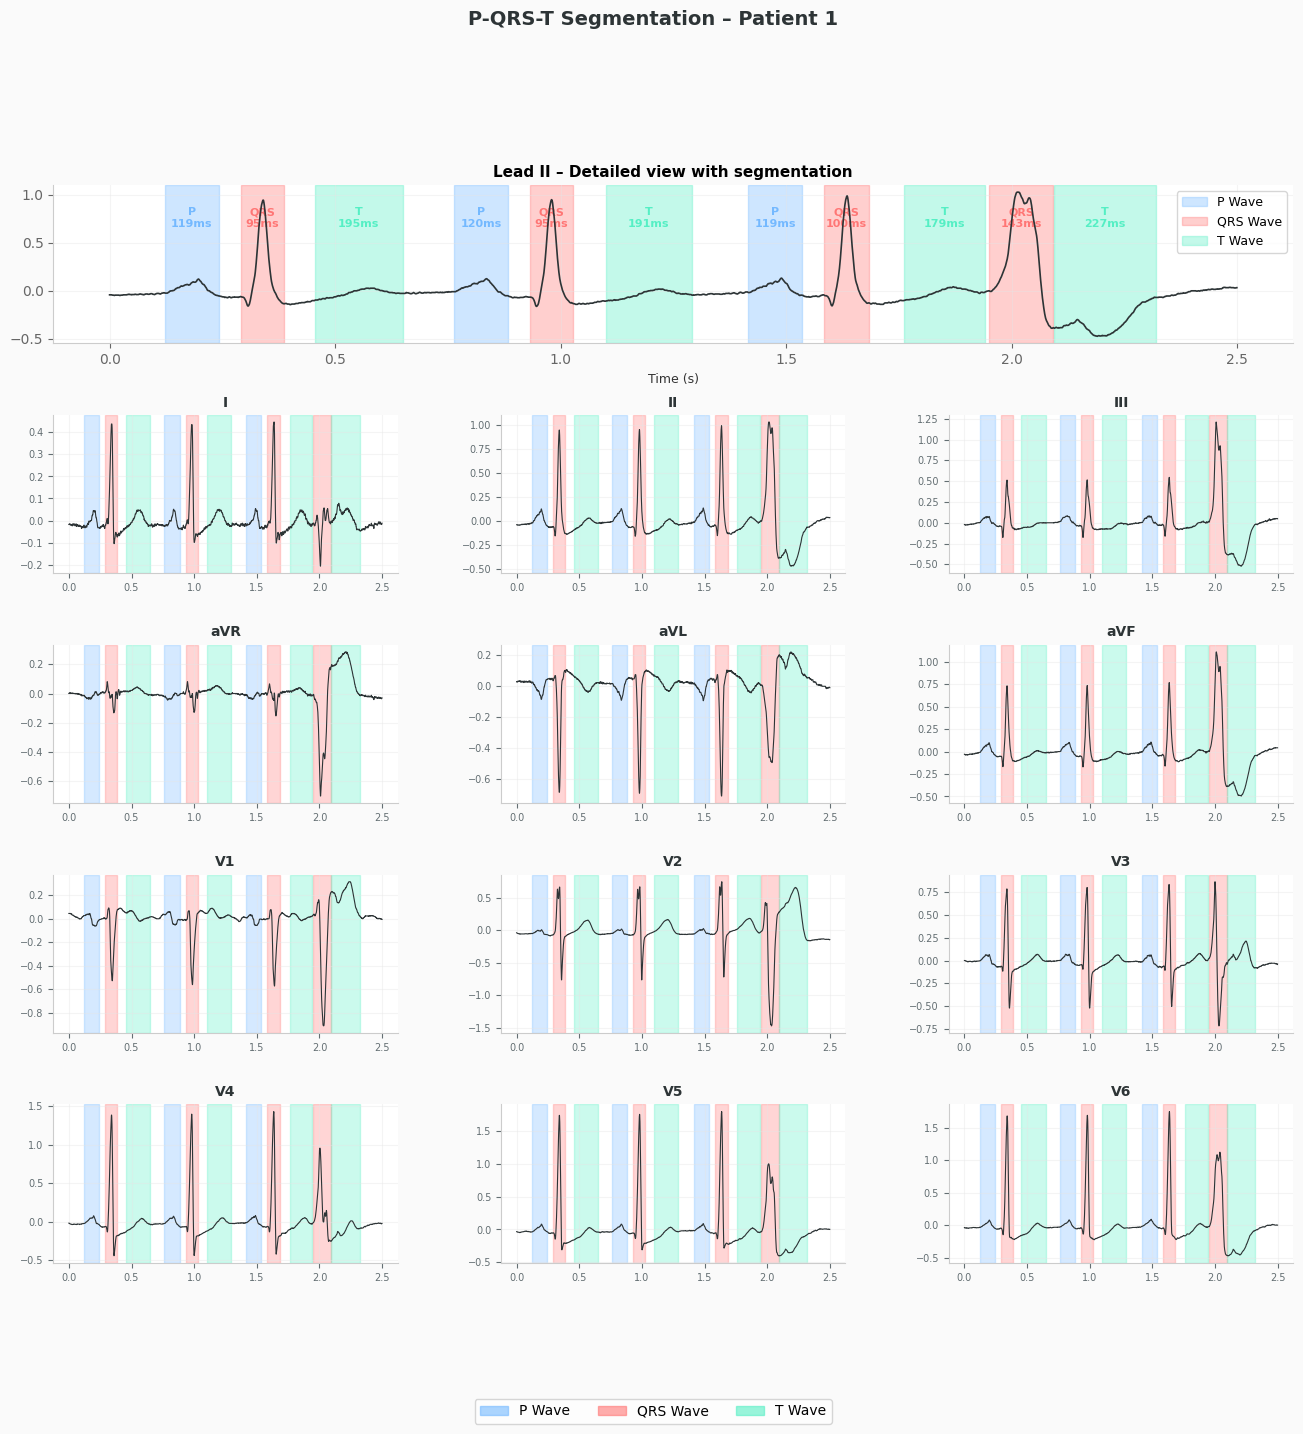

In [30]:
TEST_IDX = 1

ecg_test = ecg_matrices[TEST_IDX]
pid_test  = identifiers.iloc[TEST_IDX][PATIENT_COL]

print(f'Segmenting test ECG (patient {pid_test})...')
mask_test = predict_ecg(ecg_test, fs=FS, model=models_ECG, normalize=True, filter=True)
segs_test = extract_segments(mask_test)

print(f'\n Detected segments:')
print_segments(segs_test)

# Full dashboard panel
plot_segmentation_summary(ecg_test, segs_test, fs=FS, patient_id=str(pid_test))


[ECG 0] Patient 0
   P  : [75–198] (123 ms), [831–947] (116 ms), [1316–1415] (99 ms)
   QRS: [235–350] (115 ms), [992–1099] (107 ms), [1476–1635] (159 ms), [1917–2060] (143 ms)
   T  : [427–674] (247 ms), [1188–1319] (131 ms), [1725–1912] (187 ms), [2097–2456] (359 ms)


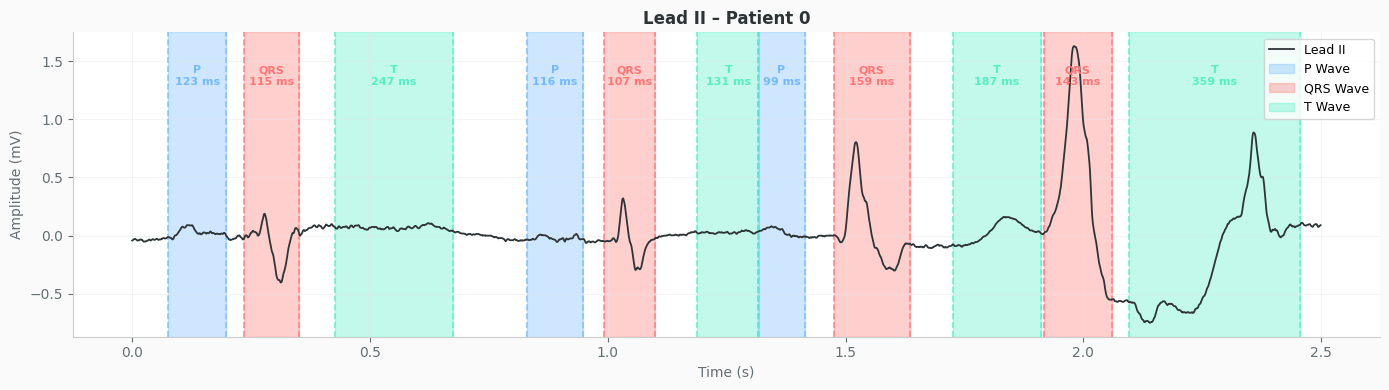


[ECG 1] Patient 1
   P  : [123–242] (119 ms), [763–883] (120 ms), [1416–1535] (119 ms)
   QRS: [291–386] (95 ms), [932–1027] (95 ms), [1584–1684] (100 ms), [1949–2092] (143 ms)
   T  : [455–650] (195 ms), [1100–1291] (191 ms), [1761–1940] (179 ms), [2093–2320] (227 ms)


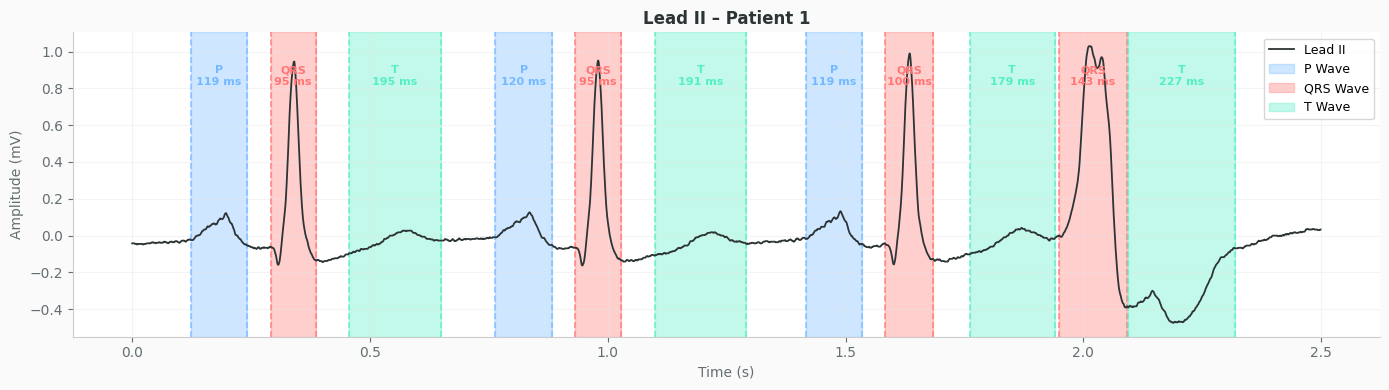


[ECG 2] Patient 2
   P  : [427–554] (127 ms), [1248–1375] (127 ms)
   QRS: [595–722] (127 ms), [1416–1547] (131 ms), [1893–2080] (187 ms)
   T  : [0–230] (230 ms), [815–1059] (244 ms), [1644–1876] (232 ms), [2081–2468] (387 ms)


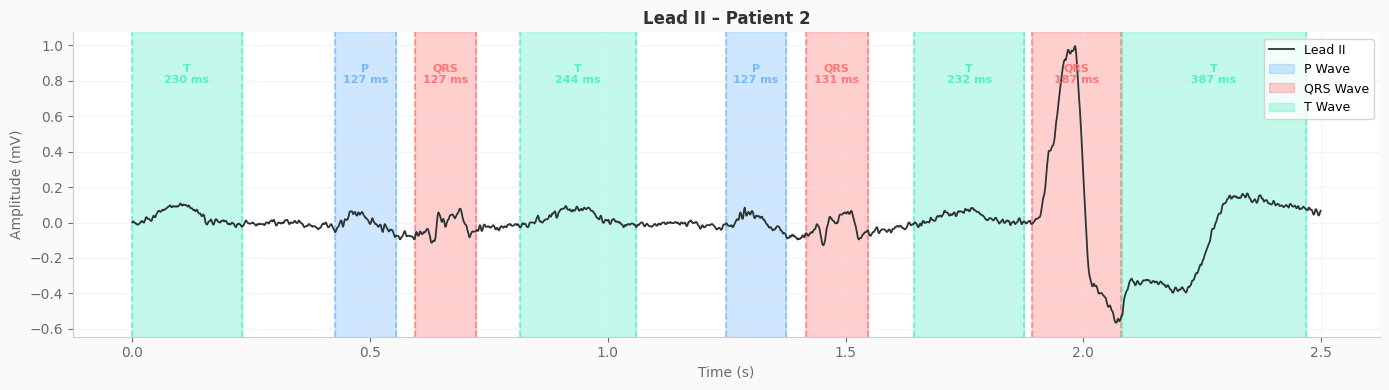


[ECG 3] Patient 3
   P  : [831–959] (128 ms), [1472–1495] (23 ms)
   QRS: [1024–1131] (107 ms), [1572–1696] (124 ms), [1921–2068] (147 ms), [2293–2420] (127 ms)
   T  : [1232–1431] (199 ms), [1693–1908] (215 ms), [2129–2292] (163 ms), [2425–2499] (74 ms)


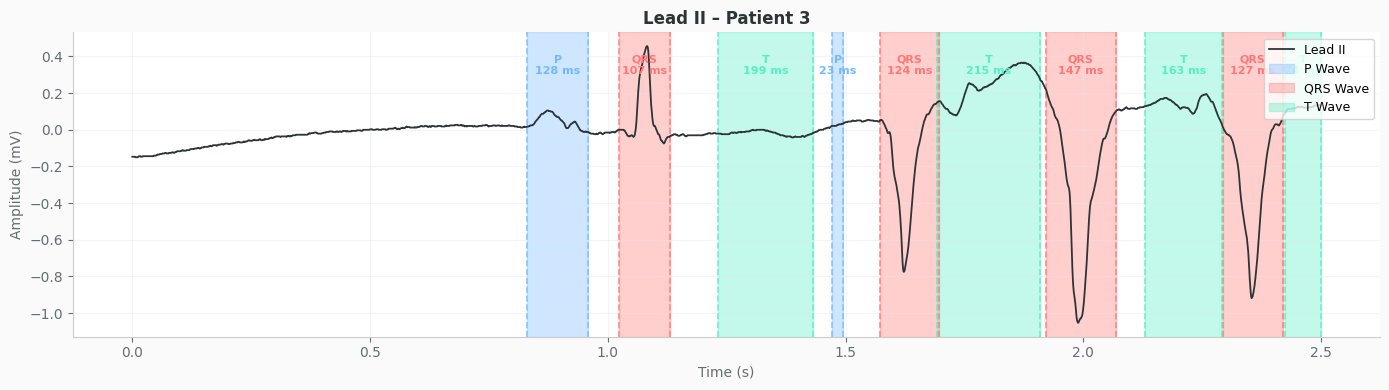

In [31]:
# Preview multiple ECGs quickly to detect issues
N_PREVIEW = 4   # how many ECGs to preview

for i in range(N_PREVIEW):
    mask = predict_ecg(ecg_matrices[i], fs=FS, model=models_ECG, normalize=True, filter=True)
    segs = extract_segments(mask)
    pid  = identifiers.iloc[i][PATIENT_COL]
    print(f'\n[ECG {i}] Patient {pid}')
    print_segments(segs)
    plot_lead_detail(ecg_matrices[i], segs, lead_idx=1, fs=FS,
                     title=f'Lead II – Patient {pid}')

### Complete segmentation of the entire dataset

Each segmentation is saved in the disk, it the process is interrumped, can be retaken from were it was left.

In [32]:
def run_segmentation_loop(ecg_matrices: List[np.ndarray],
                           models: List[torch.nn.Module],
                           cache_path: str,
                           fs: int = 1000) -> List[Dict]:
    """
    Segments all ECGs with incremental caching.
    - If the cache file exists, it loads it directly.
    - If the process gets interrupted, it resumes from the partial file.
    """
    # Check if previous run completed or saved data
    if os.path.exists(cache_path):
        print(f'Cache found. Loading segmentations from {cache_path}...')
        with open(cache_path, 'rb') as f:
            segments_list = pickle.load(f)
        print(f'   {len(segments_list)} segmentations loaded.')
        return segments_list

    print(f'Segmenting {len(ecg_matrices)} ECGs...')
    print(f'   - Device: {device.upper()}, Ensemble: {len(models)} models')
    print(f'   - Saving to: {cache_path}')
    print()

    segments_list = []
    errors        = []

    # main segmentation loop
    for idx in tqdm(range(len(ecg_matrices)), desc='Segmenting ECGs'):
        try:
            ecg  = ecg_matrices[idx]
            
            # Predict_ecg runs the 5 models
            mask = predict_ecg(ecg, fs=fs, model=models, normalize=True, filter=True)

            if mask.size == 0:
                raise ValueError('Empty segmentation')

            # Convert the voolean masks into boundary intervals
            segs = extract_segments(mask)
            segments_list.append(segs)

            del mask
            if idx % 50 == 0:
                gc.collect()

        except Exception as e:
            errors.append((idx, str(e)))
            segments_list.append({'P': [], 'QRS': [], 'T': []})  # empty placeholder

    # Save full results
    with open(cache_path, 'wb') as f:
        pickle.dump(segments_list, f)

    print(f'\n Segmentation complete:')
    print(f'   - Processed ECGs : {len(segments_list)}')
    print(f'   - Errors         : {len(errors)}')
    if errors:
        print(f'   First errors     : {errors[:5]}')
    print(f'   Saved to         : {cache_path}')

    return segments_list


segments_list = run_segmentation_loop(ecg_matrices, models_ECG, CACHE_SEG, fs=FS)

Cache found. Loading segmentations from outputs\segmentations.pkl...
   180 segmentations loaded.


Display the segmentation statistics. These values are useful to know the mean & max sizes of the QRS complexes.

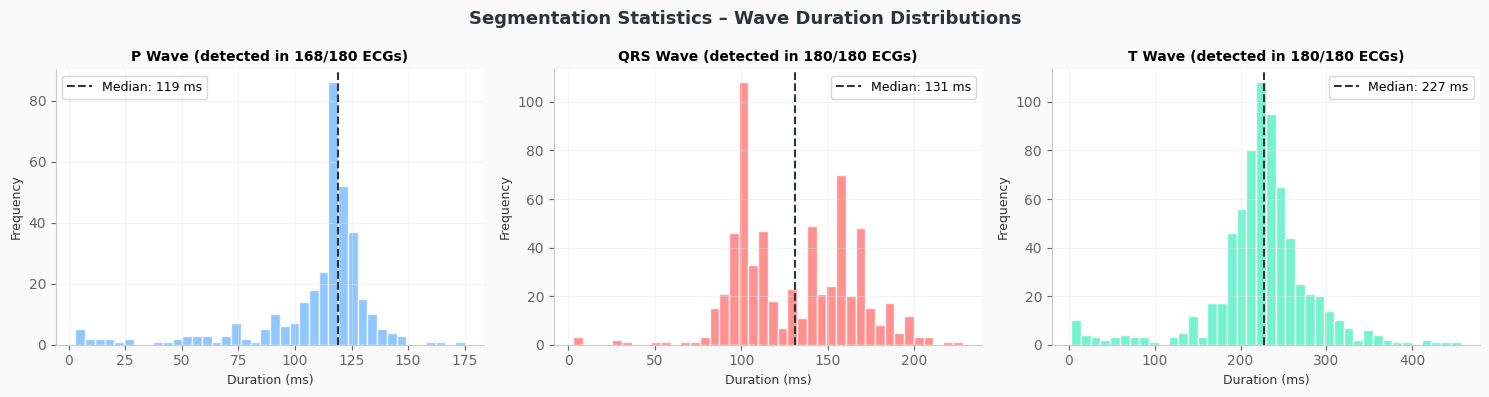


Summary:
   P  : detected in   168 ECGs (93.3%) | mean duration 110 ms, median 119 ms, range [3 - 175] ms
   QRS: detected in   180 ECGs (100.0%) | mean duration 131 ms, median 131 ms, range [3 - 228] ms
   T  : detected in   180 ECGs (100.0%) | mean duration 224 ms, median 227 ms, range [3 - 456] ms


In [ ]:
def plot_segmentation_stats(segments_list: List[Dict], fs: int = 1000):
    """Plots histograms of detected durations for P, QRS, and T waves."""
    durations = {w: [] for w in WAVE_NAMES}
    n_detected = {w: 0 for w in WAVE_NAMES}
    n_missing  = {w: 0 for w in WAVE_NAMES}

    for segs in segments_list:
        for w in WAVE_NAMES:
            intervals = segs.get(w, [])
            if intervals:
                n_detected[w] += 1
                for s, e in intervals:
                    # samples = ms when fs=1000 Hz. If fs changes, 
                    # we convert samples to ms: (e - s) * 1000 / fs
                    dur_ms = (e - s) * 1000 / fs
                    durations[w].append(dur_ms)
            else:
                n_missing[w] += 1

    # Plotting configuration
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    fig.patch.set_facecolor('#FAFAFA')
    fig.suptitle('Segmentation Statistics – Wave Duration Distributions',
                 fontsize=13, fontweight='bold', color='#2D3436')

    for ax, wave in zip(axes, WAVE_NAMES):
        color = WAVE_COLORS[wave]
        data  = durations[wave]
        if data:
            ax.hist(data, bins=40, color=color, alpha=0.8, edgecolor='white')
            
            # Ass statistical central tendency baseline
            ax.axvline(np.median(data), color='#2D3436', linewidth=1.5,
                       linestyle='--', label=f'Median: {np.median(data):.0f} ms')
            ax.legend(fontsize=9)
        ax.set_title(f'{wave} Wave (detected in {n_detected[wave]}/{len(segments_list)} ECGs)',
                     fontsize=10, fontweight='bold')
        ax.set_xlabel('Duration (ms)', fontsize=9)
        ax.set_ylabel('Frequency', fontsize=9)
        ax.grid(True, alpha=0.4)
        ax.spines[['top','right']].set_visible(False)

    plt.tight_layout()
    plt.show()

    print('\nSummary:')
    for w in WAVE_NAMES:
        pct = n_detected[w] / len(segments_list) * 100
        d   = durations[w]
        if d:
            print(f'   {w:3s}: detected in {n_detected[w]:>5} ECGs ({pct:.1f}%) | '
                  f'mean duration {np.mean(d):.0f} ms, '
                  f'median {np.median(d):.0f} ms, '
                  f'range [{np.min(d):.0f} - {np.max(d):.0f}] ms')


plot_segmentation_stats(segments_list, fs=FS)

### R peak alignment

Shifts each ECG so that the R-peak is located exactly at second 2.0.  
ECGs requiring a displacement greater than max_shift_samples are discarded as outliers.

In [35]:
def align_to_r_peak(ecg_matrices: List[np.ndarray],
                    segments_list: List[Dict],
                    fs: int = 1000,
                    target_second: float = 2.0,
                    max_shift_samples: int = 75
                    ) -> Tuple[List[np.ndarray], List[Dict], pd.Index]:
    """
    Aligns all ECGs so that their R-peak is fixed at the target second.

    Returns:
        aligned_ecgs     - list of aligned arrays (all sharing the same fixed final length)
        aligned_segments - updated wave boundary segment dictionaries with the same shift/crop
        kept_mask        - boolean index array to filter out corresponding 'identifiers'
    """
    target_sample = int(target_second * fs)
    orig_length   = ecg_matrices[0].shape[0]

    # Calculate the required shift for each ecg
    shifts = []
    for ecg, segs in zip(ecg_matrices, segments_list):
        qrs_list = segs.get('QRS', [])
        if not qrs_list:
            shifts.append(0)
            continue
        
        # Find the QRS complex whose midpoint is closest to our target alignment sample (2 sec)
        closest = min(qrs_list, key=lambda q: abs((q[0]+q[1])//2 - target_sample))
        qs, qe   = closest
        
        # Extract R-peak position by locating the absolute maximum value inside Lead II (idx 1)
        r_peak  = qs + int(np.argmax(np.abs(ecg[qs:qe+1, 1])))
        
        # Positive shift means moving right (padding start)
        # Negative shift means moving left
        shifts.append(target_sample - r_peak)

    shifts = np.array(shifts)

    # Discard ECGs needing a shift larger than max_shift_samples as outliers
    outlier_mask = np.abs(shifts) > max_shift_samples
    kept_mask    = ~outlier_mask
    kept_indices = np.where(kept_mask)[0]

    # Dynamically determine maximum displacement to truncate arrays uniformly
    normal_shifts = shifts[kept_mask]
    max_right = int(max(0, normal_shifts.max()))
    final_len = orig_length - max_right

    print(f' Aligned to R-peak:')
    print(f'   Preserved ECGs   : {kept_mask.sum()} / {len(ecg_matrices)}')
    print(f'   Discarded Outliers : {outlier_mask.sum()}')
    print(f'   Original → final length : {orig_length} → {final_len} samples ({final_len/fs:.3f} s)')
    print(f'   R-peak absolute anchor sample: {target_sample}')

    # Apply temporal shift and crop arrays
    aligned_ecgs     = []
    aligned_segments = []

    for i in tqdm(kept_indices, desc='Aligning ECGs'):
        ecg   = ecg_matrices[i]
        segs  = segments_list[i]
        shift = int(shifts[i])

        # Allocate memory for the shifted array and edge-pad boundaries
        shifted = np.empty_like(ecg)
        if shift > 0:
            shifted[shift:, :] = ecg[:-shift, :]
            shifted[:shift, :] = ecg[0, :]  # Repeat first sample for stability
        elif shift < 0:
            a = abs(shift)
            shifted[:-a, :] = ecg[a:, :]
            shifted[-a:, :] = ecg[-1, :] # Repeat last sample for stability
        else:
            shifted = ecg.copy()

        # Uniformly truncate arrays to ensure consistent dimensions across the batch
        cropped = shifted[0:final_len, :]
        aligned_ecgs.append(cropped)

        # Update and clip the dictionary wave intervals based on the applied shift
        new_segs = {w: [] for w in WAVE_NAMES}
        for w, intervals in segs.items():
            for s, e in intervals:
                cs = s + shift
                ce = e + shift
                if ce >= 0 and cs < final_len:
                    # Clip interval boundaries to remain within the newly cropped signal space
                    new_segs[w].append((max(0, cs), min(final_len - 1, ce)))
        aligned_segments.append(new_segs)

    # Sanity check to verify all processed tensors share the exact same sequence dimensions
    shapes = [e.shape[0] for e in aligned_ecgs]
    assert min(shapes) == max(shapes), f'Inconsistent sequence lengths found: {set(shapes)}'
    print(f'\nAll aligned ECGs match final matrix shape: {aligned_ecgs[0].shape}')

    return aligned_ecgs, aligned_segments, kept_mask


# Execute the peak alignment process
aligned_ecgs, aligned_segments, kept_mask = align_to_r_peak(
    ecg_matrices, segments_list, fs=FS
)

# Align the index of target dataframe tracking the labels/demographic features
aligned_identifiers = identifiers[kept_mask].reset_index(drop=True)
print(f'\n   Aligned metadata identifiers tracking dataset rows: {len(aligned_identifiers)}')

 Aligned to R-peak:
   Preserved ECGs   : 178 / 180
   Discarded Outliers : 2
   Original → final length : 2500 → 2426 samples (2.426 s)
   R-peak absolute anchor sample: 2000


Aligning ECGs:   0%|          | 0/178 [00:00<?, ?it/s]

Aligning ECGs: 100%|██████████| 178/178 [00:00<00:00, 4710.68it/s]


All aligned ECGs match final matrix shape: (2426, 12)

   Aligned metadata identifiers tracking dataset rows: 178


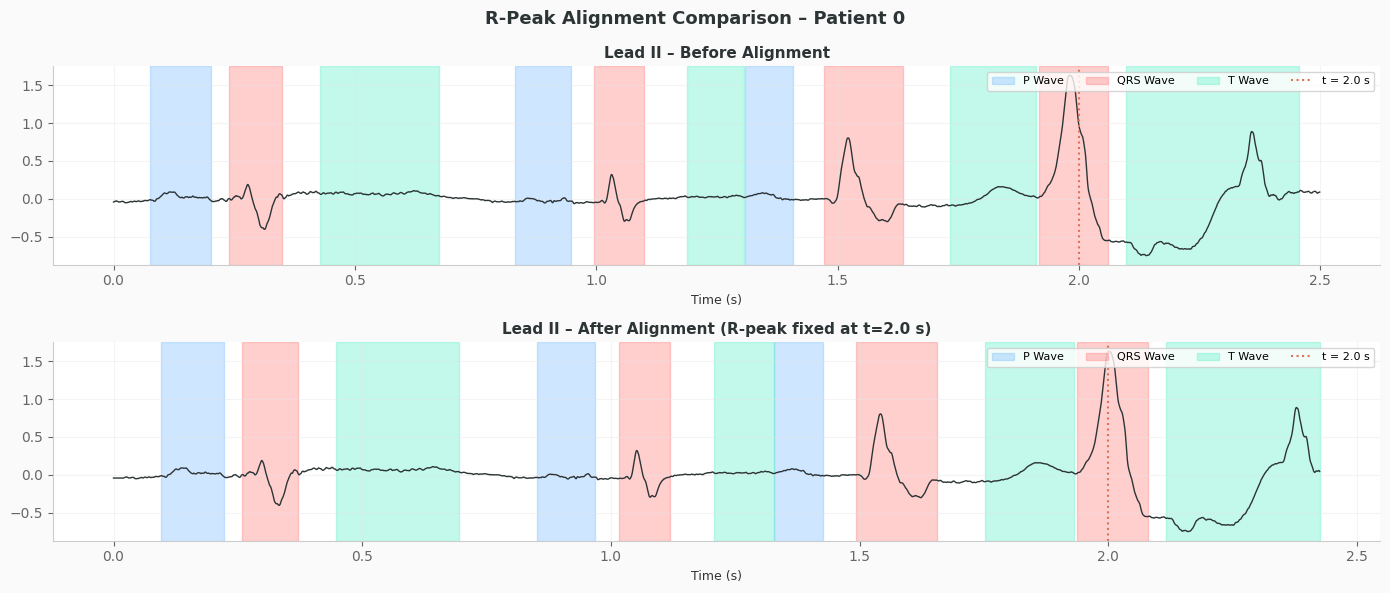

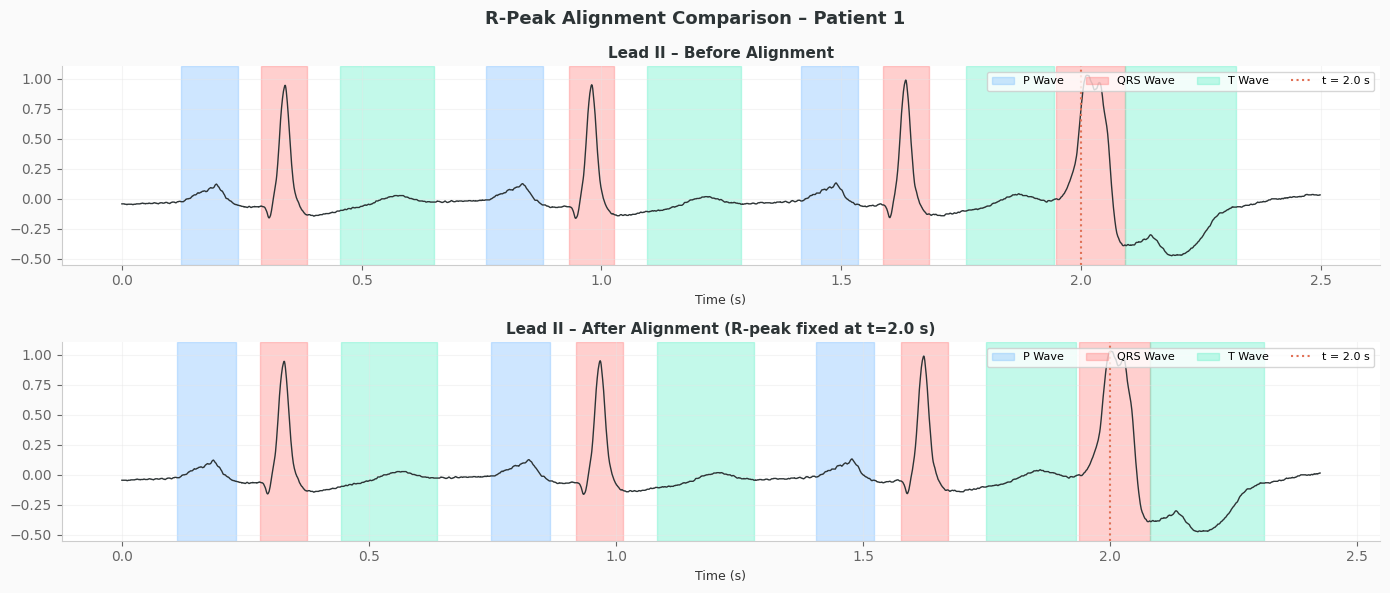

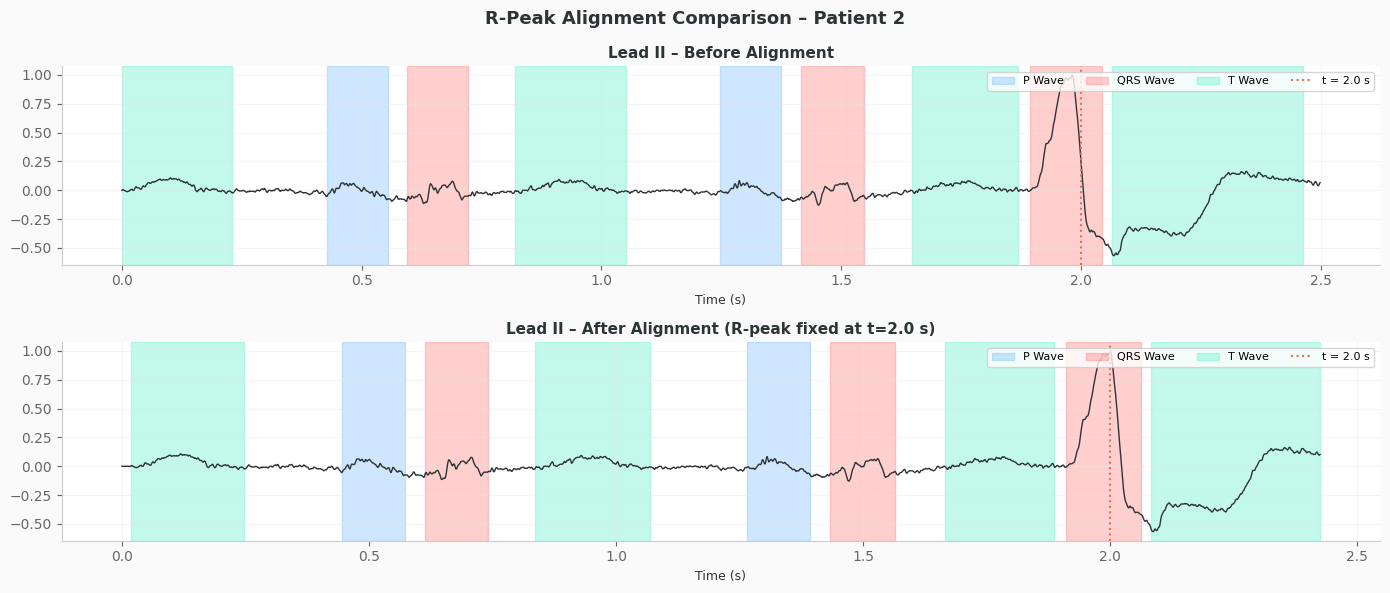

In [36]:
def plot_before_after_alignment(ecg_before: np.ndarray, segs_before: Dict,
                               ecg_after: np.ndarray,  segs_after: Dict,
                               fs: int = 1000, patient_id: str = ''):
    """Compares Lead II wave profiles before and after R-peak anchor alignment."""
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 6), sharex=False)
    fig.patch.set_facecolor('#FAFAFA')

    # Unpack structural elements to loop through both states
    for ax, ecg, segs, label in [
        (ax1, ecg_before, segs_before, 'Before Alignment'),
        (ax2, ecg_after,  segs_after,  'After Alignment (R-peak fixed at t=2.0 s)'),
    ]:
        sig = ecg[:, 1]  # Extract Lead II
        x   = np.arange(len(sig)) / fs
        ax.plot(x, sig, color=SIGNAL_COLOR, linewidth=1.0)
        
        for wave, color in WAVE_COLORS.items():
            for j, (s, e) in enumerate(segs.get(wave, [])):
                ax.axvspan(s/fs, e/fs, color=color, alpha=0.35,
                           label=f'{wave} Wave' if j == 0 else None)
        
        # Add a visual indicator at the 2.0-second alignment threshold
        ax.axvline(2.0, color='#E17055', linewidth=1.5, linestyle=':', label='t = 2.0 s')
        ax.set_title(f'Lead II – {label}', fontsize=11, fontweight='bold', color='#2D3436')
        ax.set_xlabel('Time (s)', fontsize=9)
        ax.grid(True, alpha=0.4)
        ax.spines[['top','right']].set_visible(False)
        ax.legend(loc='upper right', fontsize=8, frameon=True,
                  facecolor='white', edgecolor='#CCCCCC', ncol=4)

    pid_str = f' – Patient {patient_id}' if patient_id else ''
    fig.suptitle(f'R-Peak Alignment Comparison{pid_str}', fontsize=13,
                 fontweight='bold', color='#2D3436')
    plt.tight_layout()
    plt.show()


# Plotting loop
N_COMPARE = 3

# Track backwards from the clean mask to extract original arrays for comparison
kept_original_indices = np.where(kept_mask)[0]

for i in range(min(N_COMPARE, len(aligned_ecgs))):
    orig_i = kept_original_indices[i]
    pid    = aligned_identifiers.iloc[i][PATIENT_COL]
    
    plot_before_after_alignment(
        ecg_matrices[orig_i],  segments_list[orig_i],
        aligned_ecgs[i],       aligned_segments[i],
        fs=FS, patient_id=str(pid)
    )

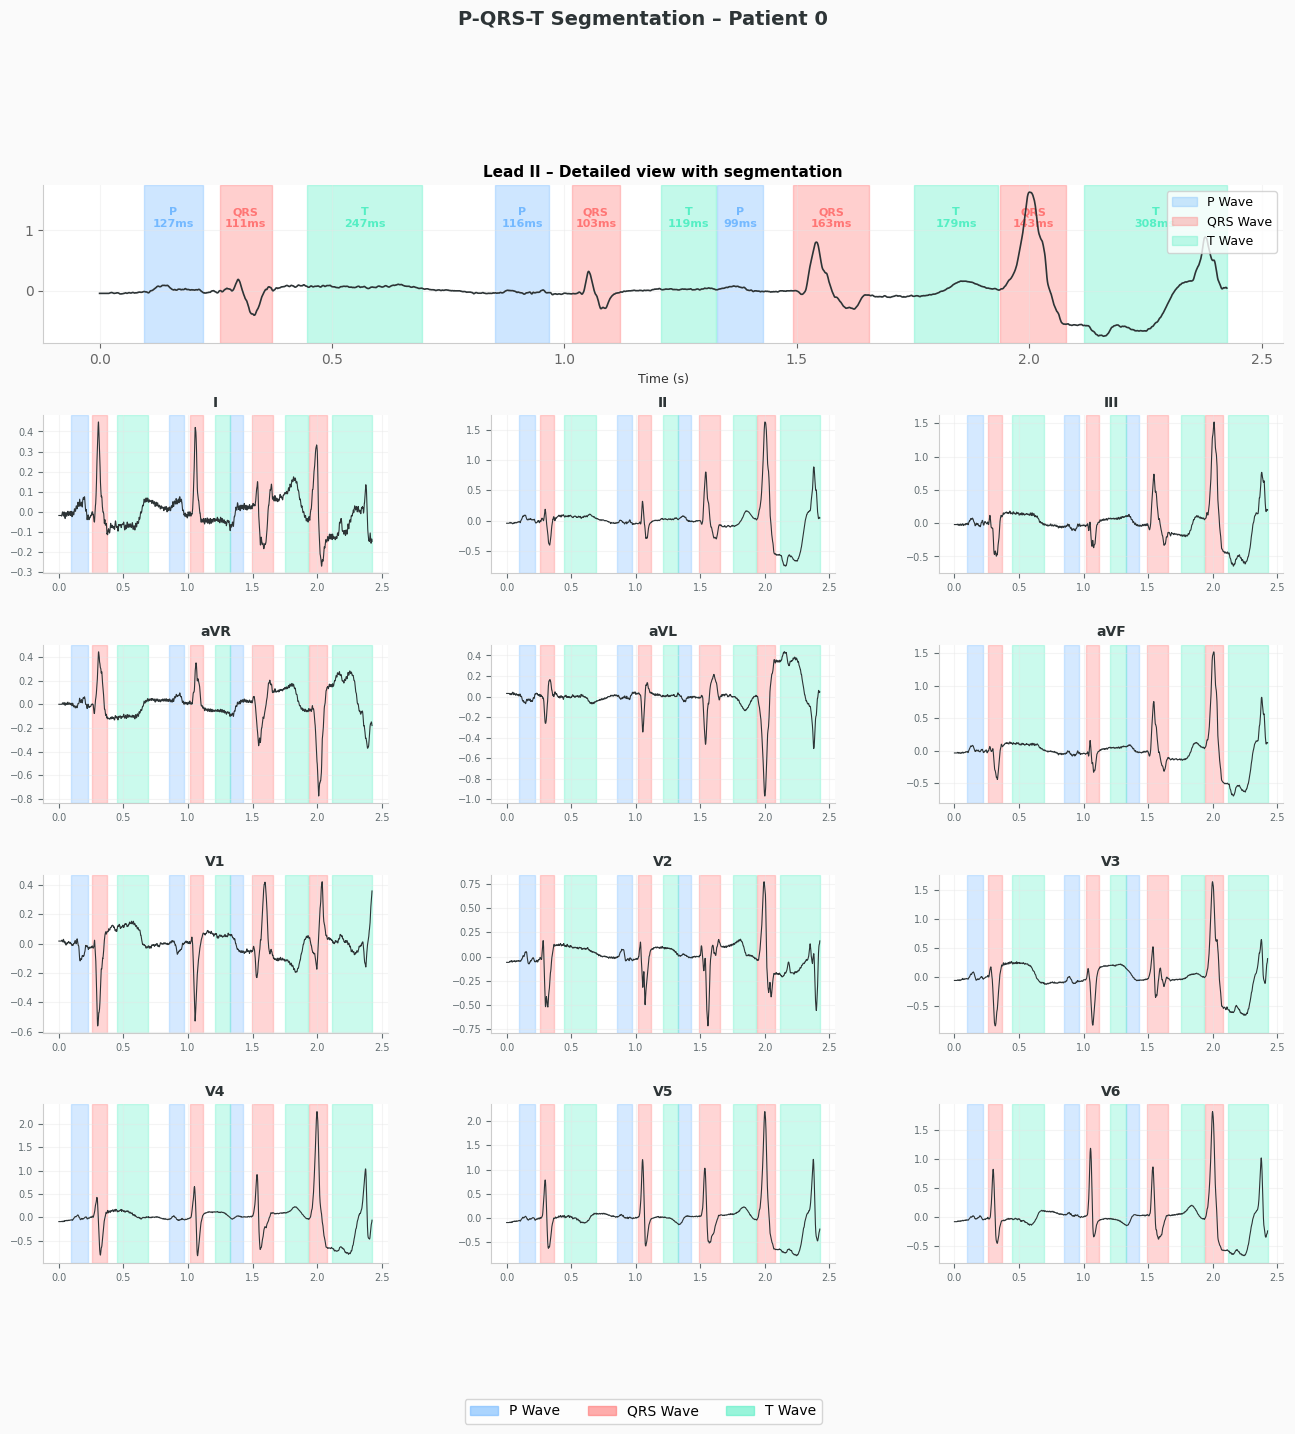

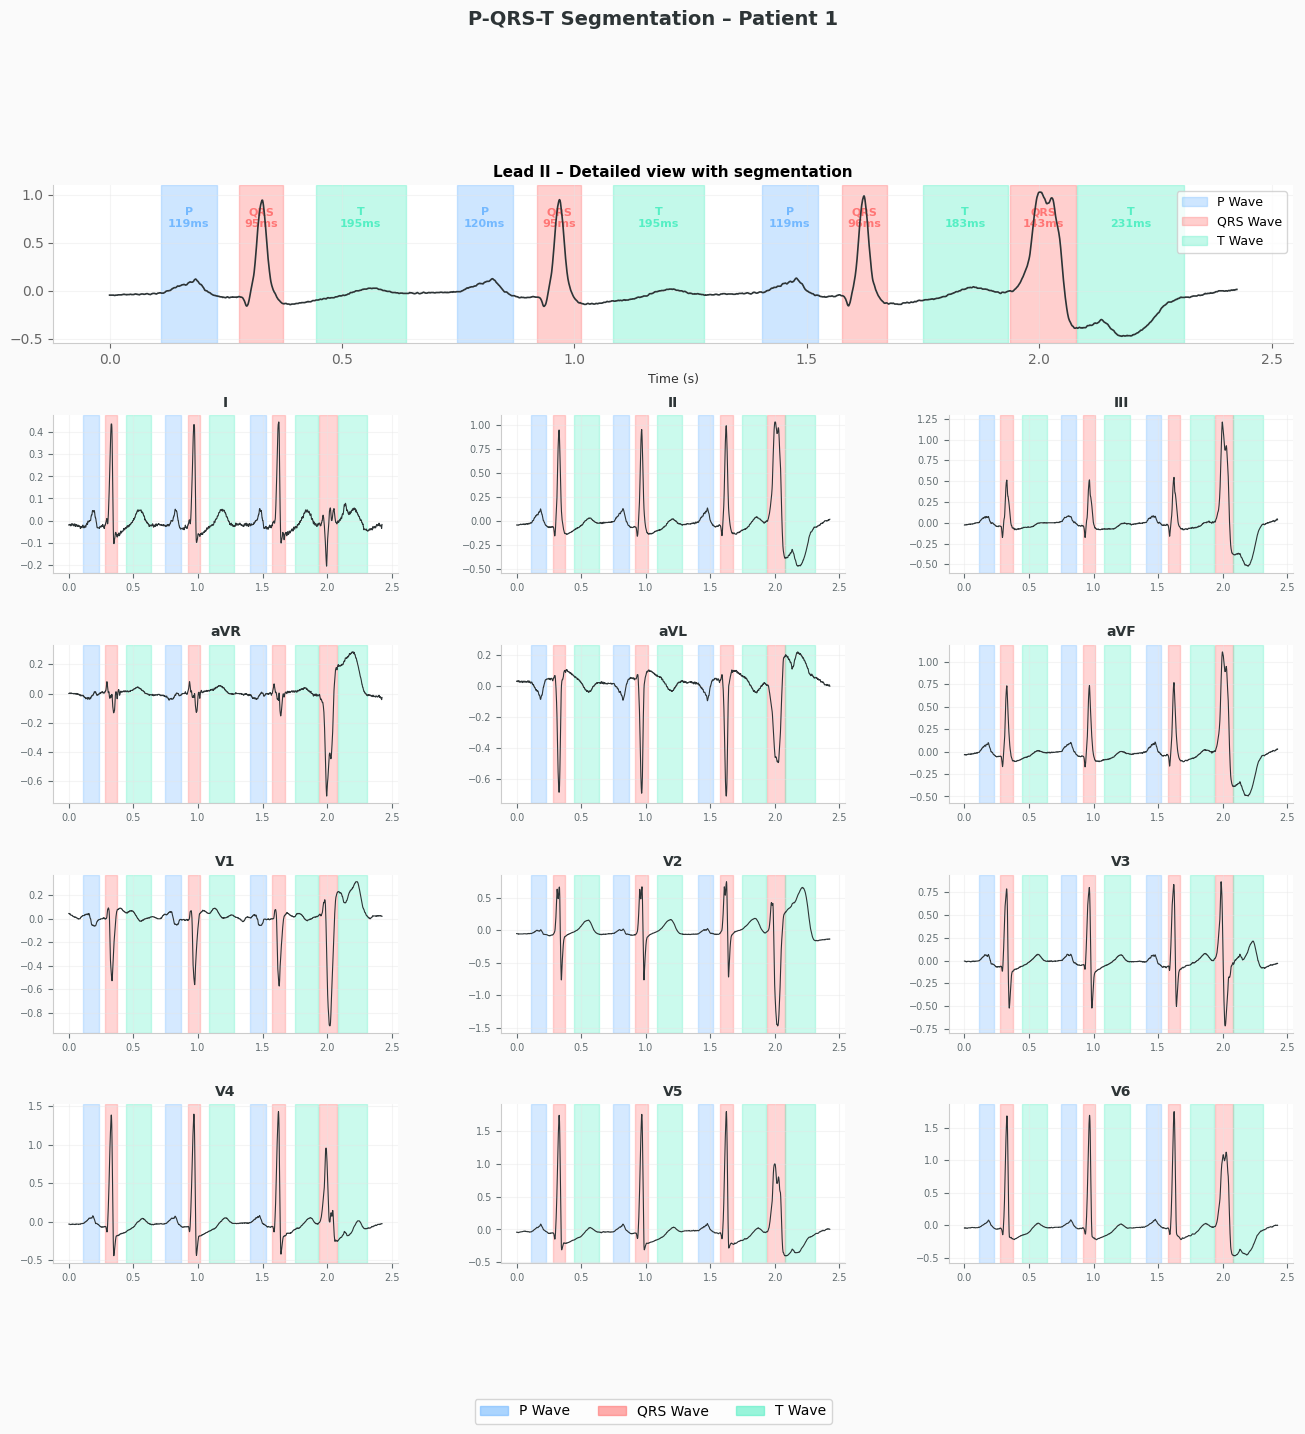

In [37]:
# Complete panel for aligned QRS
N_FULL_PLOTS = 2

for i in range(min(N_FULL_PLOTS, len(aligned_ecgs))):
    pid = aligned_identifiers.iloc[i][PATIENT_COL]
    plot_segmentation_summary(aligned_ecgs[i], aligned_segments[i],
                               fs=FS, patient_id=str(pid))

### Extract the last QRS
Given that the recordings include the 4 beats before the arrhythmia (with the 4th being the pathological beat), we only selected to keep the QRS complex of the last beat to predict the site of origin.

In [38]:
def extract_last_qrs(aligned_ecgs: List[np.ndarray],
                     aligned_segments: List[Dict],
                     fs: int = 250,
                     margin_sec: float = 0.02  # 20 ms extra margin on both sides
                     ) -> Tuple[List[np.ndarray], List[Dict], np.ndarray, int]:
    """
    Finds the synchronized QRS complex used as alignment anchor (around second 2.0),
    computes the real maximum distance with respect to the detected R-peak, and
    extracts a homogeneous, optimal window for Deep Learning models using 
    Zero-Padding if it collides with array boundaries.
    """
    margin_samples = int(margin_sec * fs)
    target_sample = int(2.0 * fs)  # Reference sample where the aligned peak sits (sample 500)

    dist_to_start_list = []
    dist_to_end_list = []
    valid_indices = []
    r_peaks_absolute = []

    # Pipeline tracking counters
    total_initial = len(aligned_ecgs)
    lost_due_to_missing_qrs = 0
    boundary_corrected_count = 0  # Tracks how many signals were salvaged using padding

    #  LOCATE SYNCHRONIZED QRS AND COMPUTE WINDOW STATISTICS 
    for i, (ecg, segs) in enumerate(zip(aligned_ecgs, aligned_segments)):
        qrs_intervals = segs.get('QRS', [])

        # Look for the QRS interval containing or closest to second 2.0
        aligned_qrs = None
        for qs, qe in qrs_intervals:
            # Check if second 2.0 falls inside the interval or close to its midpoint
            if qs <= target_sample <= qe or abs((qs + qe) // 2 - target_sample) < 50:
                aligned_qrs = (qs, qe)
                break

        # If the segmentation model missed the anchor window, extract the first available QRS complex to prevent unnecessary data loss.
        if aligned_qrs is None and len(qrs_intervals) > 0:
            aligned_qrs = qrs_intervals[0]

        # Discard signal only if the model failed to detect any QRS complex across the file
        if aligned_qrs is None:
            lost_due_to_missing_qrs += 1
            continue

        qs, qe = aligned_qrs
        # Locate the precise absolute maximum within Lead II (col index 1) to define the R-peak
        r_peak = qs + int(np.argmax(np.abs(ecg[qs:qe+1, 1])))

        # Save relative distance boundaries with respect to the absolute R-peak position
        dist_to_start_list.append(r_peak - qs)
        dist_to_end_list.append(qe - r_peak)
        valid_indices.append(i)
        r_peaks_absolute.append(r_peak)

    if not valid_indices:
        raise ValueError("No patients possess a valid segmented QRS complex around second 2.0.")

    # Filter with the overall absolute maximums to preserve wide or abnormal morphologies
    max_dist_to_start = int(np.max(dist_to_start_list))
    max_dist_to_end = int(np.max(dist_to_end_list))

    # Define uniform template window dimensions
    samples_before_r = max_dist_to_start + margin_samples
    samples_after_r = max_dist_to_end + margin_samples
    total_expected_length = samples_before_r + samples_after_r

    print(f"   Synchronized QRS Statistics (at {fs} Hz):")
    print(f"   Max Distance R-peak ➔ QRS Start : {max_dist_to_start} samples ({max_dist_to_start/fs*1000:.1f} ms)")
    print(f"   Max Distance R-peak ➔ QRS End   : {max_dist_to_end} samples ({max_dist_to_end/fs*1000:.1f} ms)")
    print(f"   Final Applied Window (w/ margin): {samples_before_r} before and {samples_after_r} after R")
    print(f"   CNN Uniform Matrix Target Size  : {total_expected_length} samples ({(total_expected_length)/fs*1000:.1f} ms)\n")

    # UNIFORM CROP EXTRACTION WITH ADAPTIVE ZERO-PADDING 
    qrs_ecgs = []
    qrs_segments = []
    kept_mask = np.zeros(len(aligned_ecgs), dtype=bool)

    counter = 0
    for i, (ecg, segs) in enumerate(zip(aligned_ecgs, aligned_segments)):
        if i not in valid_indices:
            continue

        r_peak_absolute = r_peaks_absolute[counter]
        counter += 1

        # Establish theoretical crop boundaries based on maximum historical widths
        start_crop = r_peak_absolute - samples_before_r
        end_crop = r_peak_absolute + samples_after_r

        # Calculate safe overlap slices within the actual array limits
        real_start = max(0, start_crop)
        real_end = min(ecg.shape[0], end_crop)

        # Log instances where the theoretical footprint overshoots array boundaries
        if start_crop < 0 or end_crop > ecg.shape[0]:
            boundary_corrected_count += 1

        # Extract the real available segment data
        cropped_real = ecg[real_start:real_end, :].copy()

        # If the extracted snippet is shorter than expected, pad the rest with zeros
        if cropped_real.shape[0] < total_expected_length:
            cropped_ecg = np.zeros((total_expected_length, ecg.shape[1]), dtype=cropped_real.dtype)

            # Map the exact inner destination offsets for the real sub-array slice
            pad_start = 0 if start_crop >= 0 else abs(start_crop)
            pad_end = pad_start + cropped_real.shape[0]

            cropped_ecg[pad_start:pad_end, :] = cropped_real
        else:
            cropped_ecg = cropped_real

        qrs_ecgs.append(cropped_ecg)

        # Shift inner segmentation dictionaries to preserve consistency with the new crop timeline
        new_segs = {w: [] for w in segs.keys()}
        for wave, intervals in segs.items():
            for s, e in intervals:
                cs = s - start_crop
                ce = e - start_crop
                if ce >= 0 and cs < total_expected_length:
                    # Clip boundaries to keep intervals strictly confined inside the output tensor space
                    new_segs[wave].append((max(0, cs), min(total_expected_length - 1, ce)))

        qrs_segments.append(new_segs)
        kept_mask[i] = True


    total_preserved = len(qrs_ecgs)
    print(f"   Initial patients (from Section 8)      : {total_initial}")
    print(f"   Final preserved patients               : {total_preserved} ({(total_preserved/total_initial)*100:.1f}%)")
    
    return qrs_ecgs, qrs_segments, kept_mask, samples_before_r


# Execute the standardized deep learning window cropping extraction pipeline
fourth_qrs_ecgs, fourth_qrs_segments, kept_mask_qrs4, samples_before_r = extract_last_qrs(
    aligned_ecgs,
    aligned_segments,
    fs=250,
    margin_sec=0.02
)

   Synchronized QRS Statistics (at 250 Hz):
   Max Distance R-peak ➔ QRS Start : 153 samples (612.0 ms)
   Max Distance R-peak ➔ QRS End   : 114 samples (456.0 ms)
   Final Applied Window (w/ margin): 158 before and 119 after R
   CNN Uniform Matrix Target Size  : 277 samples (1108.0 ms)

   Initial patients (from Section 8)      : 178
   Final preserved patients               : 178 (100.0%)


In [39]:
print(fourth_qrs_ecgs[0].shape)  # Verify that samples have the expected size (n samples x 12 leads)

(277, 12)


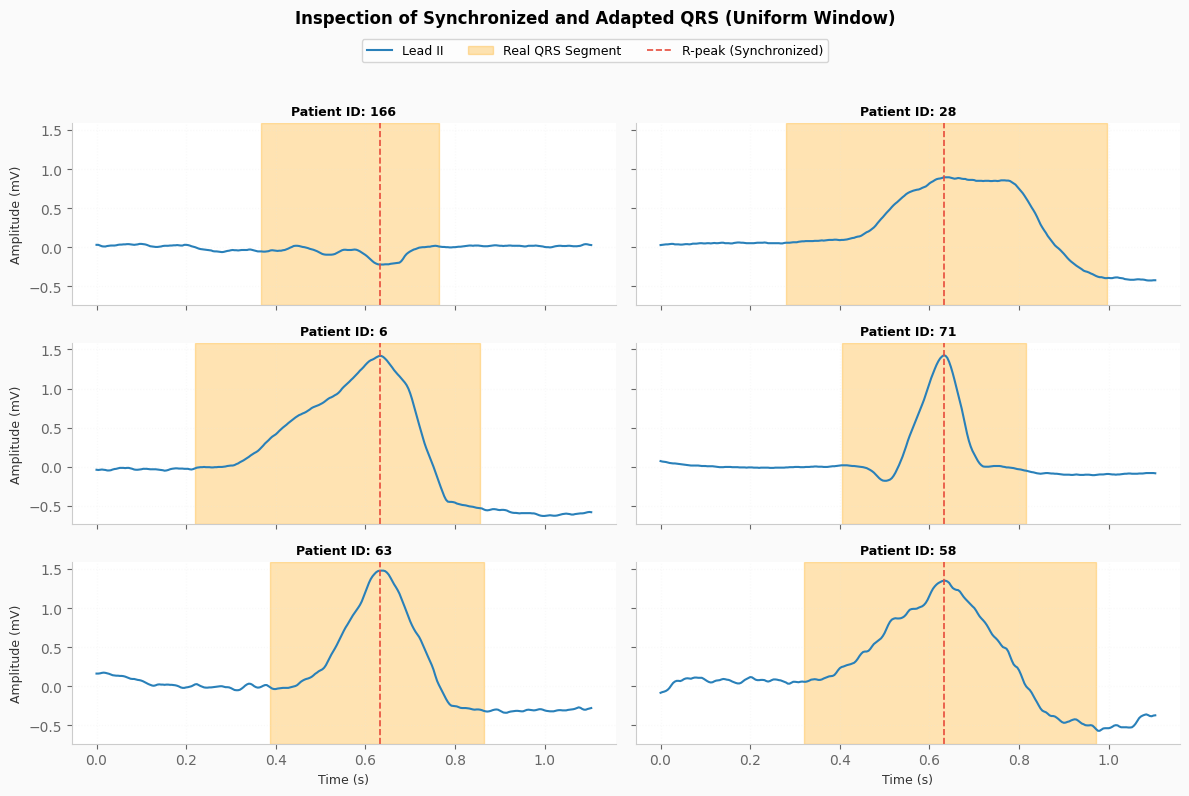

In [40]:
def plot_qrs_mean_grid_6_patients(fourth_qrs_ecgs, fourth_qrs_segments, identifiers_df, samples_before_r, fs=250):
    """
    Plots a 3x2 grid displaying the synchronized and uniform QRS window 
    for 6 randomly selected patient ECG signals.
    """
    num_patients = len(fourth_qrs_ecgs)
    random.seed(42)
    indices_to_plot = random.sample(range(num_patients), min(6, num_patients))

    fig, axes = plt.subplots(3, 2, figsize=(12, 8), sharex=True, sharey=True)
    axes = axes.flatten()

    # Calculate where the R-peak sits chronologically along the shared time-axis array
    t_r_peak = samples_before_r / fs  

    for i, idx in enumerate(indices_to_plot):
        ax = axes[i]
        sig = fourth_qrs_ecgs[idx][:, 1]  # Extract Lead II signal trace
        x = np.arange(len(sig)) / fs

        # Draw the main ECG trace snippet
        ax.plot(x, sig, color='#2980B9', linewidth=1.5, label='Lead II' if i == 0 else "")

        # Shade the background footprint corresponding to the actual detected QRS interval
        segs = fourth_qrs_segments[idx].get('QRS', [])
        for j, (s, e) in enumerate(segs):
            ax.axvspan(s/fs, e/fs, color='orange', alpha=0.3,
                       label='Real QRS Segment' if (i == 0 and j == 0) else "")

        # Add a vertical marker at the absolute synchronized R-peak alignment coordinate
        ax.axvline(t_r_peak, color='#E74C3C', linewidth=1.2, linestyle='--',
                   label='R-peak (Synchronized)' if i == 0 else "")

        # Map patient metadata identifier from the aligned dataframe rows
        pid = identifiers_df.iloc[idx][PATIENT_COL]
        ax.set_title(f"Patient ID: {pid}", fontsize=9, fontweight='bold')
        ax.grid(True, alpha=0.2, linestyle=':')
        ax.spines[['top', 'right']].set_visible(False)

    # Apply global outer axis labels cleanly across shared grid dimensions
    for a in axes[-2:]: a.set_xlabel("Time (s)", fontsize=9)
    for a in axes[::2]:  a.set_ylabel("Amplitude (mV)", fontsize=9)

    fig.legend(loc='upper center', bbox_to_anchor=(0.5, 0.96), ncol=3, fontsize=9)
    fig.suptitle("Inspection of Synchronized and Adapted QRS (Uniform Window)",
                 fontsize=12, fontweight='bold', y=0.99)

    plt.tight_layout(rect=[0, 0, 1, 0.93])
    plt.show()
    return


# Execute the layout plot by applying the boolean indexing mask directly inside the call
plot_qrs_mean_grid_6_patients(
    fourth_qrs_ecgs,
    fourth_qrs_segments,
    aligned_identifiers[kept_mask_qrs4],  # Pandas data filter slice applied 
    samples_before_r,
    fs=250
)

### Save results

In [41]:
# Execute optimized 4th QRS crop based on REAL MAXIMUM
# margin_sec=0.02 adds a 20 ms safety padding of real data on both sides
fourth_qrs_ecgs, fourth_qrs_segments, kept_mask_qrs4, samples_before_r = extract_last_qrs(
    aligned_ecgs, aligned_segments, fs=250, margin_sec=0.02
)

# Filter patient metadata identifiers consistently for the 4th QRS matrix
qrs_identifiers = aligned_identifiers[kept_mask_qrs4].reset_index(drop=True)

# Define file storage paths 
CACHE_QRS = os.path.join(os.path.dirname(CACHE_ALI), 'aligned_qrs.pkl')
CACHE_QRS_IDS = os.path.join(os.path.dirname(CACHE_IDS), 'qrs_identifiers.pkl')

# Save 4th QRS data objects
with open(CACHE_QRS, 'wb') as f:
    pickle.dump(fourth_qrs_ecgs, f)
print(f' Aligned QRS segments saved → {CACHE_QRS}')

with open(CACHE_QRS_IDS, 'wb') as f:
    pickle.dump(qrs_identifiers, f)
print(f' QRS identifiers metadata saved → {CACHE_QRS_IDS}')


# Final Summary 
print(f'\nFinal Pipeline Summary:')
print(f'   - Aligned ECGs (Full Length)   : {len(aligned_ecgs)}')
print(f'   - Shape of each full ECG array : {aligned_ecgs[0].shape}  (samples × 12 leads)')
print(f'   - Extracted 4th QRS segments   : {len(fourth_qrs_ecgs)}')
print(f'   - Shape of each QRS segment    : {fourth_qrs_ecgs[0].shape}   (samples × 12 leads)')
print(f'   - Column features in QRS IDs   : {list(qrs_identifiers.columns)}')

if 'Outcome_B' in qrs_identifiers.columns:
    print(f'   Outcome_B Distribution (inside QRS subset):')
    print(qrs_identifiers['Outcome_B'].value_counts().to_string(indent=6))
if 'Outcome_C' in qrs_identifiers.columns:
    print(f'   Outcome_C Distribution (inside QRS subset):')
    print(qrs_identifiers['Outcome_C'].value_counts().to_string(indent=6))

   Synchronized QRS Statistics (at 250 Hz):
   Max Distance R-peak ➔ QRS Start : 153 samples (612.0 ms)
   Max Distance R-peak ➔ QRS End   : 114 samples (456.0 ms)
   Final Applied Window (w/ margin): 158 before and 119 after R
   CNN Uniform Matrix Target Size  : 277 samples (1108.0 ms)

   Initial patients (from Section 8)      : 178
   Final preserved patients               : 178 (100.0%)
 Aligned QRS segments saved → outputs\aligned_qrs.pkl
 QRS identifiers metadata saved → outputs\qrs_identifiers.pkl

Final Pipeline Summary:
   - Aligned ECGs (Full Length)   : 178
   - Shape of each full ECG array : (2426, 12)  (samples × 12 leads)
   - Extracted 4th QRS segments   : 178
   - Shape of each QRS segment    : (277, 12)   (samples × 12 leads)
   - Column features in QRS IDs   : ['patient_id', 'Chamber_Type']
